# Loan Approval Classification - ML

## Problem Statement
A Machine Learning Classification Model that predicts whether a loan application will be approved based on applicant and other loan related features.

## Dataset 
Loan Approval Classification Dataset
[https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data]


The target variable is `loan_status`:
- `0` → Loan not approved
- `1` → Loan approved


In [24]:
%pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load the dataset
df = pd.read_csv('../datasets/loan_data.csv')

# clear the leading/trailing spaces from the column headers
df.columns = df.columns.str.strip()



## Overview of the given dataset

In [26]:
print("Dataset shape: ",df.shape)

print("\n Column information:")
df.info()

print("\n Missing values:")
print(df.isnull().sum())

print("\n First 5 rows:")
display(df.head())

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe().T)

Dataset shape:  (45000, 14)

 Column information:
<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64 

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1



Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


## Exploratory Data Analysis
### Target Distribution
The dataset contains the applicant's age, demographic info, financial information, loan characteristics, previous loan behaviour

The target variable `loan_status`, indicates if the loan was approved or not.

In [28]:
# check the target balance, i.e, what fraction is approved vs not approved
print("\n--- Target Balance ---")
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True))


--- Target Balance ---
loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


In [29]:
target = 'loan_status'

# categorize the features;
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

numeric_features.remove(target)

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Categorical features:
['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


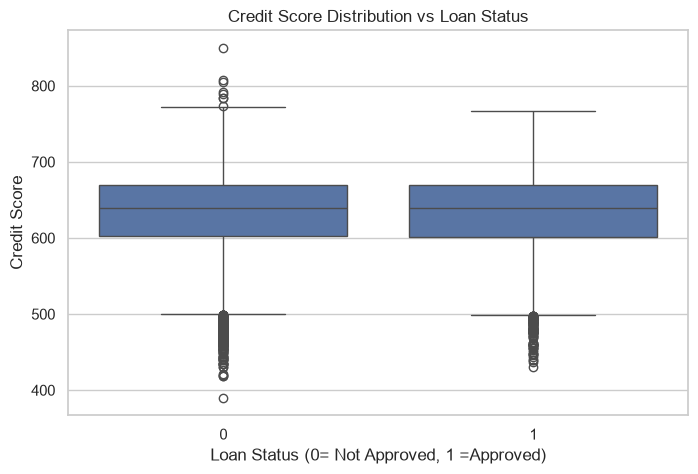

In [38]:

plt.figure(figsize=(8, 5))

# plot 1: credit Score vs loan Approval
sns.boxplot(data=df, x='loan_status', y='credit_score')

plt.title('Credit Score Distribution vs Loan Status')
plt.xlabel('Loan Status (0= Not Approved, 1 =Approved)')
plt.ylabel('Credit Score')

plt.show()

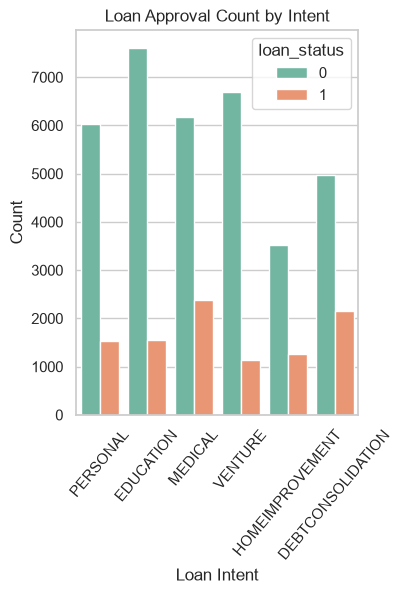

In [37]:
plt.figure(figsize=(8, 5))

# plot 2: loan Intent vs approval status
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='loan_intent', hue='loan_status', palette='Set2')
plt.title('Loan Approval Count by Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.xticks(rotation=50) # so that the intents don't overlap ;)

plt.show()



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

categorical_cols = [
    'person_gender', 
    'person_education', 
    'person_home_ownership', 
    'loan_intent', 
    'previous_loan_defaults_on_file'
]

# one hot encode -> sepearate columns of 0s and 1s
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# create a matrix X, having all vars, except the answer -> status column
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status'] # vector y having correct answer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #20:80 split
) 

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) # mean-> standard deviation scaling -> transform the training data
X_test_scaled = scaler.transform(X_test) # transform test data using the same scaling


print("Preprocessing complete!!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")



Preprocessing complete!!
Training features shape: (36000, 22)
Testing features shape: (9000, 22)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":RandomForestClassifier(n_estimators=100, random_state=42) #100 individual trees
}

results =[]

# training the model and evaluating...

for name, model in models.items():
    X_tr = X_train_scaled if name =="Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test


    # train the model 
    model.fit(X_tr, y_train)

    # make predictions on unseen data
    y_pred = model.predict(X_te)


    results.append({
        "Model": name,
        "Accuracy": round(float(accuracy_score(y_test,y_pred)), 4),
        "Precision": round(float(precision_score(y_test, y_pred)), 4),
        "Recall": round(float(recall_score(y_test,y_pred)), 4),
        "F1 Score": round(float(f1_score(y_test, y_pred)), 4)
    })


results_df = pd.DataFrame(results)
print("\n -- Model Evaluation Results --")
print(str(results_df))


 -- Model Evaluation Results --
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8998     0.7896  0.7485    0.7685
1        Random Forest    0.9299     0.9015  0.7685    0.8297


/var/folders/gb/b7bv9wc95kn1v1dlm10t_g380000gn/T/ipykernel_39267/823043067.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


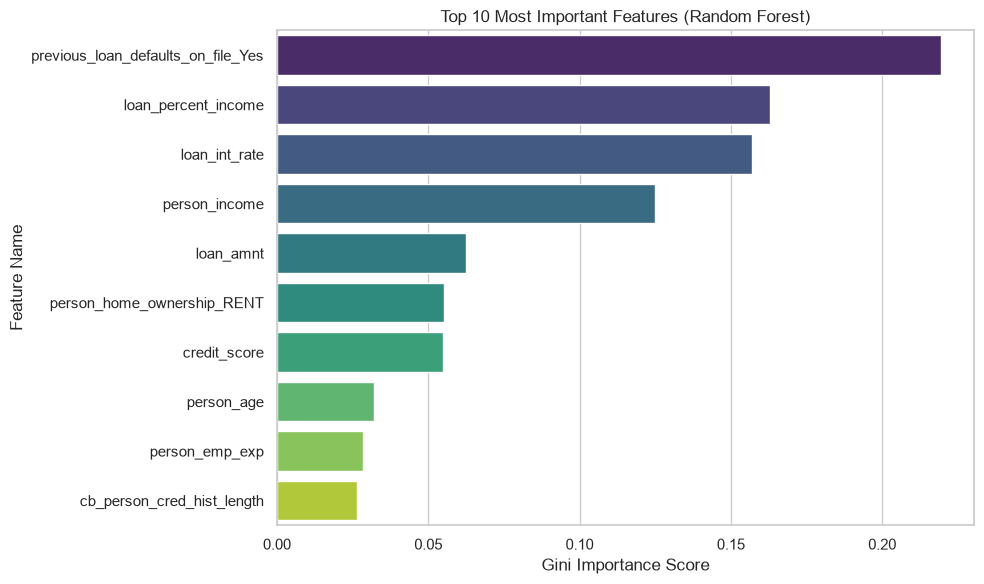

In [ ]:
# Plotting these stuff in a bar chart

import matplotlib.pyplot as plt
import seaborn as sns

rf_model = models["Random Forest"]


# NOTE(future-me): Gini importance basically means, how well a feature separates the 0s and 1s,
# and classifies the 'impurity'
# and, also determines how much impurity dropped dues to a split in the decision tree!
importances = rf_model.feature_importances_

feature_names = X.columns # gets matrix X to align the var name


# store in dataFrame and sort descending, because that is standard practice.
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10), 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    legend=False,
    palette='viridis',
)

plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Gini Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()